# Лабораторная работа №6 (1)

Данные в файле  `M3_152_0.csv`
Данные по годам. 
Информация о данных отсутствует.

Задача:
1. Подобрать параметры модели ARIMA
2. Описать процедуру подбора в комментариях
3. Построить прогноз на 4 года вперед

In [1]:
# импорт необходимых библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score

In [2]:
df = pd.read_csv('M3_152_0.csv')
df.head()

,id,value
0,0,5717.0
1,1,6374.0
2,2,5837.5
3,3,7318.4
4,4,4613.0


<Axes: >

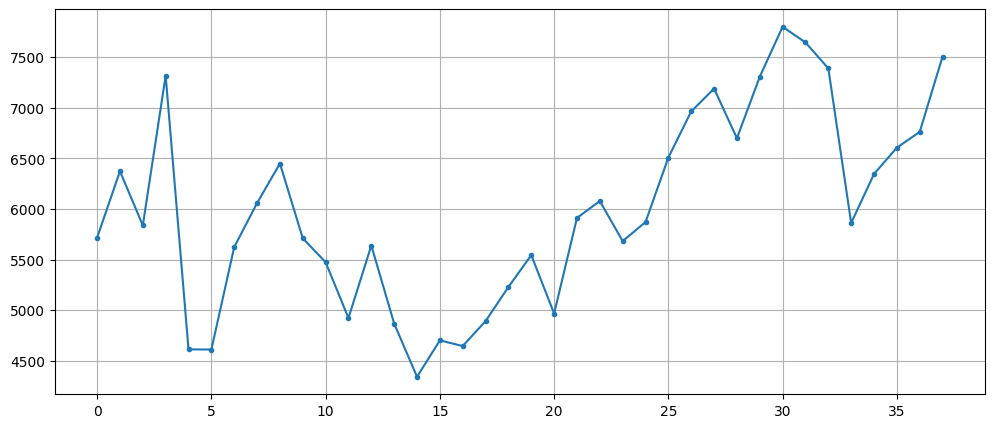

In [3]:
y = df['value']
fig, ax = plt.subplots(figsize = (12, 5))

y.plot(ax = ax, grid = True, linewidth = 1.5, marker = 'o', markersize = 3)

## Проверка стационарности данных

Перед применением ARIMA необходимо проверить, являются ли данные стационарными.
Используем расширенный тест Дики-Фуллера (ADF test).

In [4]:
adf_result = adfuller(y)
f'p-value: {adf_result[1]:.6f}'

'p-value: 0.192801'

In [5]:
is_stationary = adf_result[1] < 0.05
f'Ряд стационарен: {is_stationary}'

'Ряд стационарен: False'

In [6]:
d = 0
if not is_stationary:
    
    y_diff = y.diff().dropna()
    adf_diff = adfuller(y_diff)
    print(f'После первой дифференцировки, p-value: {adf_diff[1]:.6f}')
    d = 1
    if adf_diff[1] >= 0.05:
        
        y_diff = y_diff.diff().dropna()
        adf_diff2 = adfuller(y_diff)
        print(f'После второй дифференцировки, p-value: {adf_diff2[1]:.6f}')
        d = 2

f'Степень дифференцирования (d): {d}'

После первой дифференцировки, p-value: 0.000000


'Степень дифференцирования (d): 1'

## Анализ ACF/PACF графиков

ACF (Autocorrelation Function) помогает определить q (MA порядок)

PACF (Partial Autocorrelation Function) помогает определить p (AR порядок)

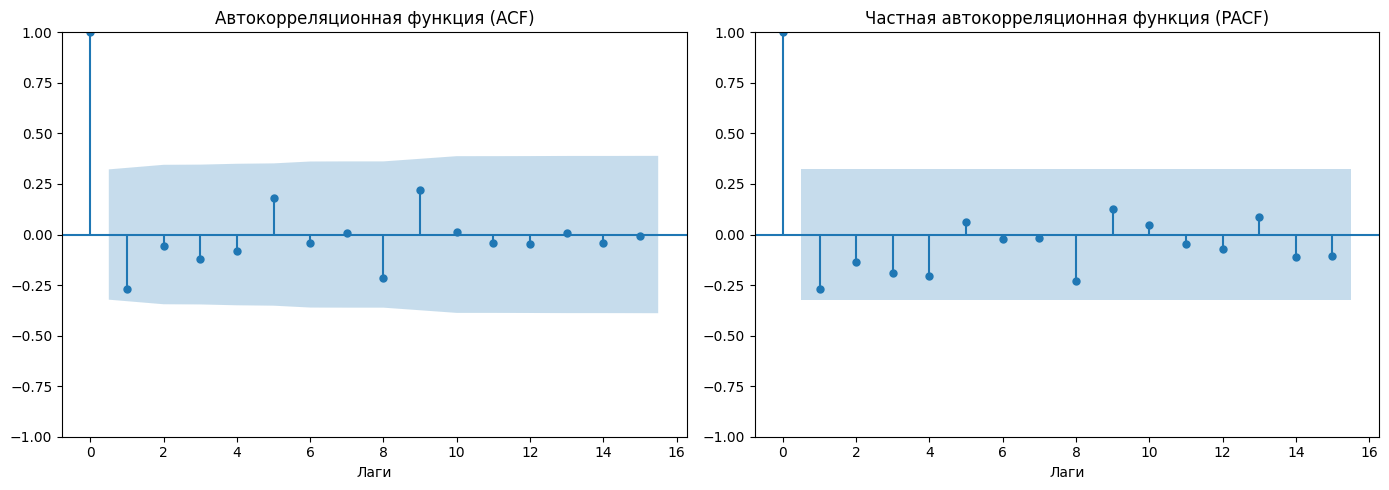

In [7]:
y_for_acf = y_diff if d > 0 else y

max_lags = min(15, len(y_for_acf) // 2 - 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ACF график
plot_acf(y_for_acf, lags=max_lags, ax=axes[0])
axes[0].set_title('Автокорреляционная функция (ACF)')
axes[0].set_xlabel('Лаги')

# PACF график
plot_pacf(y_for_acf, lags=max_lags, ax=axes[1], method='ywm')
axes[1].set_title('Частная автокорреляционная функция (PACF)')
axes[1].set_xlabel('Лаги')

plt.tight_layout()
plt.show()

- сезонности нет - лаг 12 близок к нулю (-0.045), значимых пиков нет
- подходит простая **ARIMA**, SARIMA не нужна
- ряд уже стационарный (ACF быстро затухает к нулю), `d=0`
- xарактер ACF/PACF: нет чёткого обрыва/затухания - смешанный паттерн

## Автоматический подбор параметров

Используем функцию auto_arima.

In [8]:
model = auto_arima(
    y,
    max_p=3,
    max_d=2,
    max_q=3,
    seasonal=False,
    stepwise=True,
    trace=True,
    error_action='ignore',
    suppress_warnings=True
)

p, d, q = model.order
f'p, d, q: {p}, {d}, {q}'

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.27 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=598.299, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=598.884, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=598.159, Time=0.06 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=596.455, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.08 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.449 seconds


'p, d, q: 0, 1, 0'

In [9]:
forecast_periods = 4
forecast = model.predict(n_periods=forecast_periods)
forecast

38    7507.4
39    7507.4
40    7507.4
41    7507.4
dtype: float64

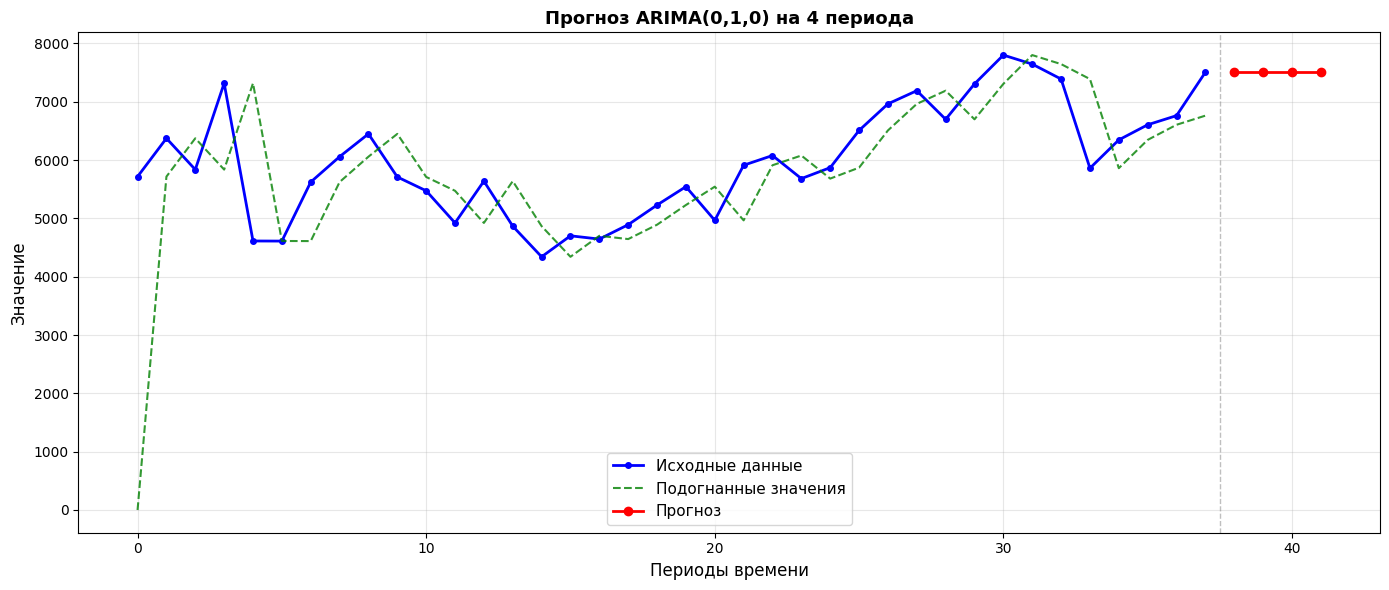

In [10]:
fig, ax = plt.subplots(figsize=(14, 6))

# Исходные данные
ax.plot(y.index, y.values, 'b-', label='Исходные данные', linewidth=2, marker='o', markersize=4)

# Подогнанные значения
fitted_values = model.predict_in_sample()
ax.plot(range(len(y)), fitted_values, 'g--', label='Подогнанные значения', linewidth=1.5, alpha=0.8)

# Прогноз
forecast_index = range(len(y), len(y) + forecast_periods)
ax.plot(forecast_index, forecast, 'r-o', label='Прогноз', linewidth=2, markersize=6)

# Оформление
ax.axvline(x=len(y)-0.5, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Периоды времени', fontsize=12)
ax.set_ylabel('Значение', fontsize=12)
ax.set_title(f'Прогноз ARIMA({p},{d},{q}) на 4 периода', 
             fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# метрики
mae = mean_absolute_error(y, fitted_values)
mape = mean_absolute_percentage_error(y, fitted_values)

print(f"MAE: {mae:.4f}")
print(f"MAPE: {mape:.2%}")

MAE: 699.0474
MAPE: 12.16%


## Выводы

- по тесту Дики-Фуллера ряд оказался нестационарным, поэтому была выбрана одна дифференцировка: $d=1$. 
- автоматический подбор `auto_arima` показал, что лучшая модель для этих данных - `ARIMA(0,1,0)`, то есть без авторегрессии и скользящего среднего. Это означает, что в ряде слабая краткосрочная зависимость, и простая модель лучше остальных описывает данные по выбранному критерию AIC.